<a href="https://colab.research.google.com/github/fikriwildann/customer-churn-prediction/blob/main/UAS_BENGKOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Customer Churn
# UAS BENGKEL KODING DATA SCIENCE
## Universitas Dian Nuswantoro

**Dataset:** Sales dan Marketing Dataset   
**Sumber:**  https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset  

### NAMA : Fikri Wildan Ariyananda
### NIM : A11.2023.15487

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# Sklearn - Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

print("✅ Library berhasil diimpor")

✅ Library berhasil diimpor


# EDA

In [ ]:
# Load Dataset
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f"Ukuran dataset: {df.shape[0]:,} baris  ×  {df.shape[1]} kolom")
df.head()

Ukuran dataset: 15,000 baris  ×  30 kolom


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
# Informasi Dataset
print('=== INFORMASI DATASET ===')
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages

In [ ]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().T

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.0,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.0,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.0,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.0,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.0,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.0,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.0,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.0,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.0,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.0,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


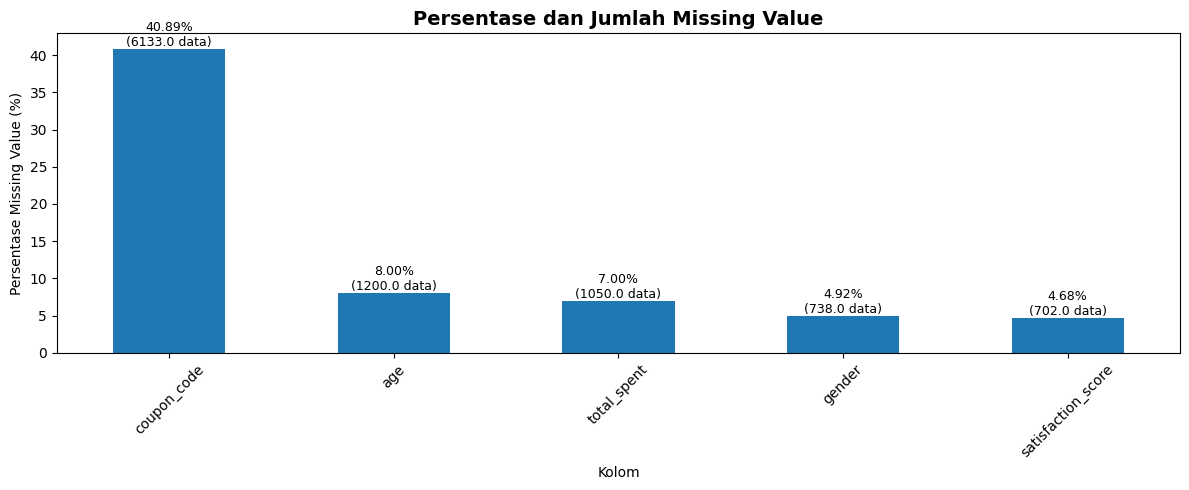

In [ ]:
# Menghitung persentase dan jumlah missing value
missing_percent = df.isnull().mean() * 100
missing_count = df.isnull().sum()

missing = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent
})


missing = missing[missing['Missing Count'] > 0]
missing = missing.sort_values(by='Missing Percent', ascending=False)

plt.figure(figsize=(12,5))

ax = missing['Missing Percent'].plot(
    kind='bar',
    color=sns.color_palette()[0]
)

for i, p in enumerate(ax.patches):
    ax.annotate(
        f'{p.get_height():.2f}%\n({missing.iloc[i]["Missing Count"]} data)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(
    'Persentase dan Jumlah Missing Value',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Kolom')
plt.ylabel('Persentase Missing Value (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

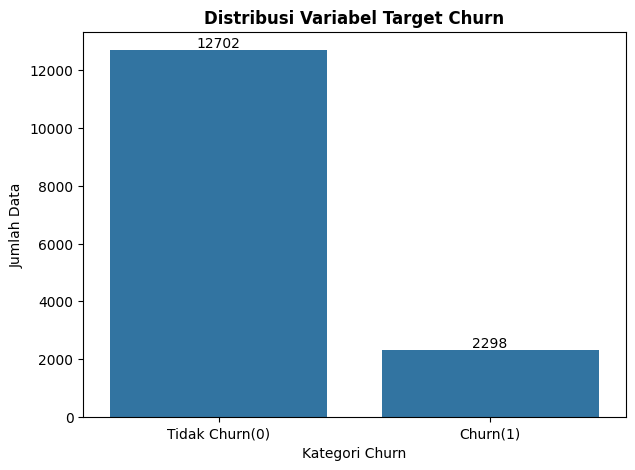

In [ ]:
# Distribusi Variabel Target (Churn)
plt.figure(figsize=(7,5))

ax = sns.countplot(x='churn', data=df)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title(
    'Distribusi Variabel Target Churn',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Kategori Churn')
plt.ylabel('Jumlah Data')

plt.xticks(
    ticks=[0, 1],
    labels=['Tidak Churn(0)', 'Churn(1)']
)

plt.show()

Kolom numerik (20): ['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


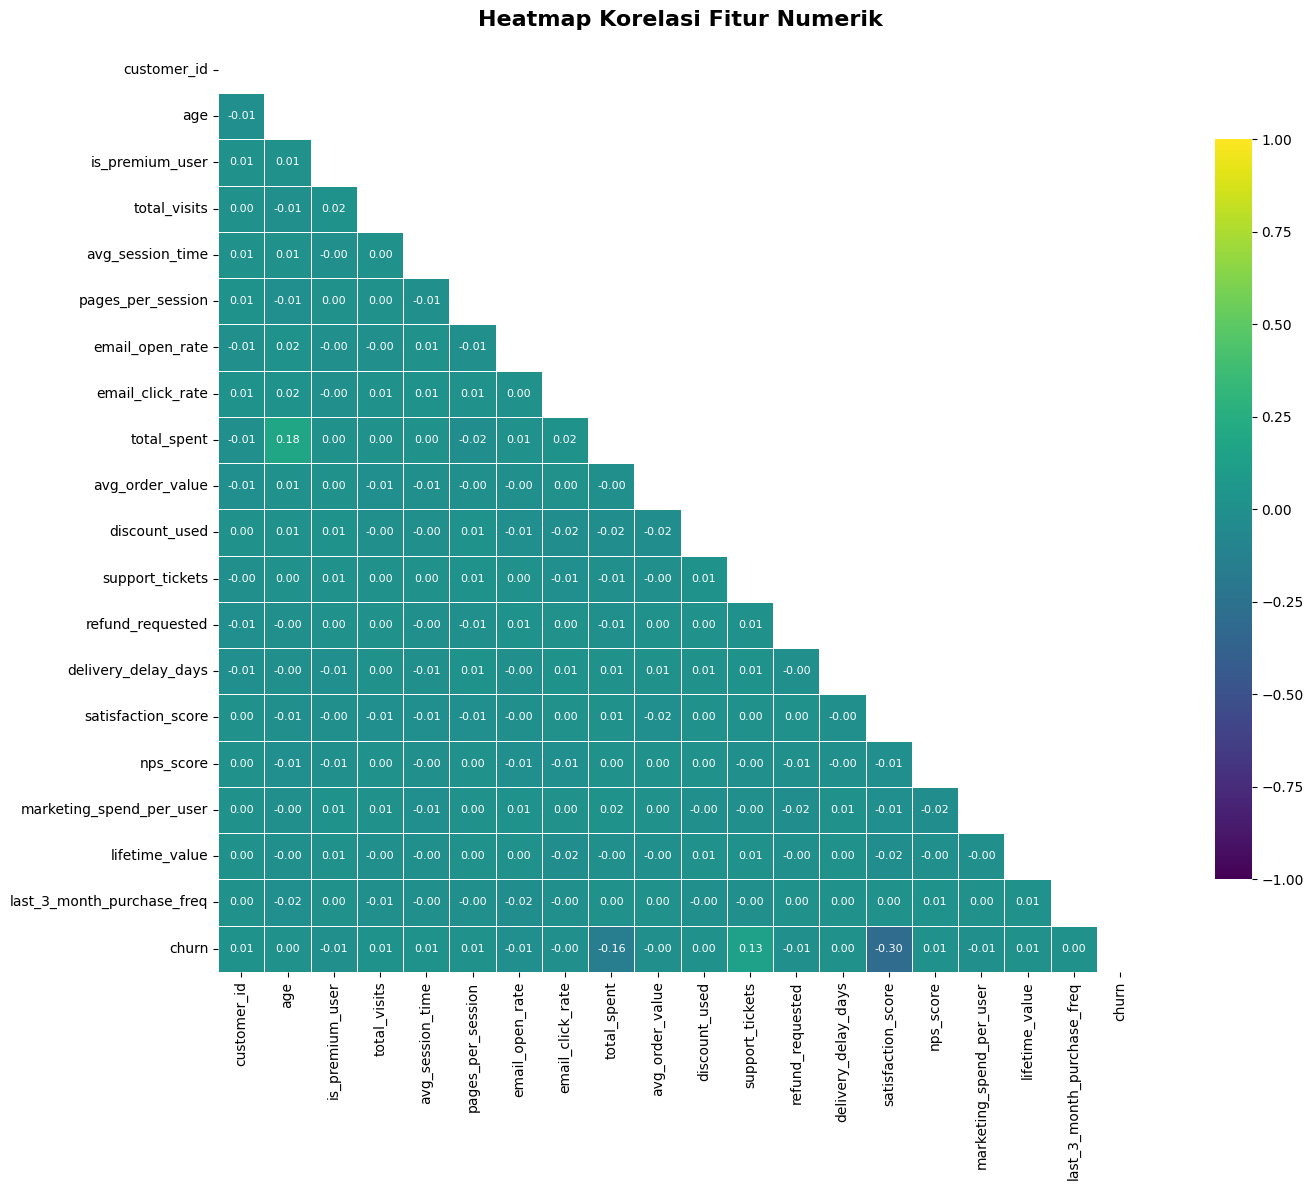


Top 10 fitur berkorelasi paling tinggi terhadap Churn:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
customer_id                 0.012208
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250


In [ ]:
# Heatmap Korelasi
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom numerik ({len(num_cols)}): {num_cols}')

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap='viridis', vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Korelasi tertinggi terhadap target 'churn' ──────────────────────────────
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print('\nTop 10 fitur berkorelasi paling tinggi terhadap Churn:')
print(churn_corr.head(10).to_string())


# Direct Modeling

In [ ]:
# Menetapkan variabel target (y) yaitu kolom Churn, serta menggunakan seluruh kolom lain sebagai fitur prediktor
df_direct = df.copy()

# Encode kolom object agar bisa langsung dilatih (Label Encoding sederhana)
le = LabelEncoder()
obj_cols = df_direct.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal yang di-encode: {obj_cols}')

for col in obj_cols:
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))

# Definisikan X dan y
X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

# Isi missing value numerik secara minimal (median) agar model bisa berjalan
X_direct = X_direct.fillna(X_direct.median(numeric_only=True))

print(f'\nShape X: {X_direct.shape}')
print(f'Shape y: {y_direct.shape}')
print(f'Distribusi target:\n{y_direct.value_counts()}')

Kolom kategorikal yang di-encode: ['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

Shape X: (15000, 29)
Shape y: (15000,)
Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


In [ ]:
# Train-Test Split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

print(f'Data Latih : {X_train_d.shape[0]:,} sampel')
print(f'Data Uji   : {X_test_d.shape[0]:,} sampel')
print(f'Proporsi   : {len(X_train_d)/(len(X_train_d)+len(X_test_d)):.0%} train / {len(X_test_d)/(len(X_train_d)+len(X_test_d)):.0%} test')

Data Latih : 12,000 sampel
Data Uji   : 3,000 sampel
Proporsi   : 80% train / 20% test


In [ ]:
# Memilih 3 model
# Model 1 — Logistic Regression (Konvensional)
lr_direct = LogisticRegression(random_state=42, max_iter=1000)

# Model 2 — Random Forest (Ensemble Bagging)
rf_direct = RandomForestClassifier(random_state=42, n_estimators=100)

# Model 3 — LR + KNN + RF (Ensemble Voting)
lr_v  = LogisticRegression(random_state=42, max_iter=1000)
knn_v = KNeighborsClassifier()
rf_v  = RandomForestClassifier(random_state=42, n_estimators=50)
voting_direct = VotingClassifier(
    estimators=[('lr', lr_v), ('knn', knn_v), ('rf', rf_v)],
    voting='hard'
)

models_direct = {
    'Logistic Regression (Direct)': lr_direct,
    'Random Forest (Direct)': rf_direct,
    'Voting Classifier (Direct)': voting_direct,
}
print('Model siap dilatih!')

Model siap dilatih!



  Logistic Regression (Direct)
  Accuracy  : 0.8477
  Precision : 0.5108
  Recall    : 0.1543
  F1-Score  : 0.2371


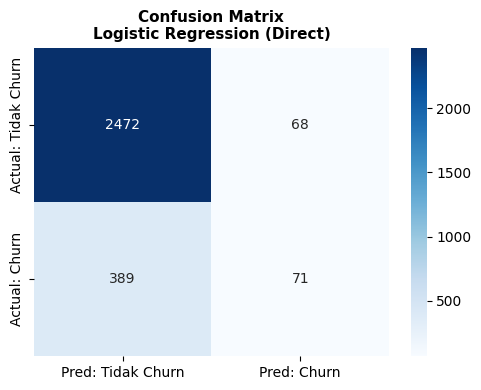


  Random Forest (Direct)
  Accuracy  : 0.8477
  Precision : 0.5053
  Recall    : 0.3130
  F1-Score  : 0.3866


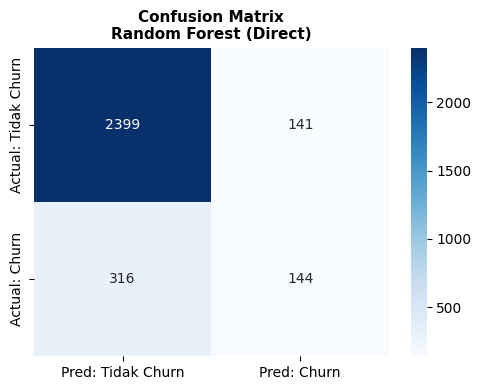


  Voting Classifier (Direct)
  Accuracy  : 0.8470
  Precision : 0.5048
  Recall    : 0.1152
  F1-Score  : 0.1876


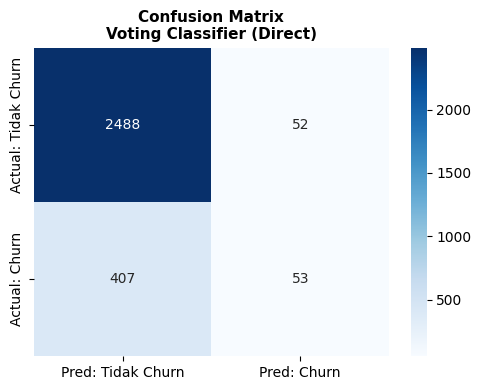

In [ ]:
# Melatih dan mengevaluasi model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Tidak Churn', 'Pred: Churn'],
                yticklabels=['Actual: Tidak Churn', 'Actual: Churn'])
    ax.set_title(f'Confusion Matrix\n{model_name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': round(acc, 4),
            'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1-Score': round(f1, 4)}


results_direct = []
for name, model in models_direct.items():
    res = evaluate_model(model, X_train_d, X_test_d, y_train_d, y_test_d, name)
    results_direct.append(res)

In [ ]:
# Rangkuman hasil direct modeling
df_result_direct = pd.DataFrame(results_direct).set_index('Model')
print('\nRangkuman Performa — Direct Modeling:')
print(df_result_direct.to_string())


Rangkuman Performa — Direct Modeling:
                              Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression (Direct)    0.8477     0.5108  0.1543    0.2371
Random Forest (Direct)          0.8477     0.5053  0.3130    0.3866
Voting Classifier (Direct)      0.8470     0.5048  0.1152    0.1876
